# Seasonal Agriculture Performance Analysis

### VOIS AICTE Batch 1 2026-2027

**Project Type:** Data Analytics  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy

## Objective

The objective of this project is to analyze agricultural performance
across different seasons and identify meaningful patterns, trends,
relationships and variations in agricultural performance.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 4000
Columns: 28


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [7]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [8]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts())


 Farm_ID
Farm_ID
SF13984    1
SF13983    1
SF13982    1
SF13981    1
SF13980    1
          ..
SF10005    1
SF10004    1
SF10003    1
SF10002    1
SF10001    1
Name: count, Length: 4000, dtype: int64

 State
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

 District
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

 Crop
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

 Season
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

 Irrigation_Method
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: 

In [9]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


In [10]:
missing_table = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_table[missing_table['Missing Values'] > 0]

,Missing Values,Missing %
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [11]:
numeric_missing_cols = [
    'Rainfall_mm',
    'Soil_Moisture_pct',
    'Yield_Tonnes_Ha'
]

for col in numeric_missing_cols:
    df[col] = df[col].fillna(df[col].median())

In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [14]:
df = df.drop_duplicates()

In [15]:
print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (4000, 28)


In [16]:
for col in ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']:
    print(f"\n{col}:")
    print(df[col].unique())


State:
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [17]:
season_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,5.63,46.31,710719.06,531804.41,178914.65,6102.20,5.89,54.47
Rabi,5.04,41.49,601526.05,513836.58,87689.47,5846.99,5.19,40.48
Zaid,4.64,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,38.22


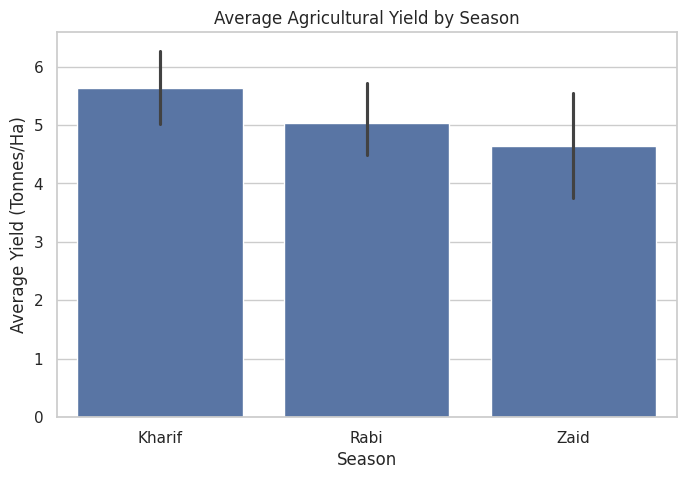

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha',
    estimator='mean'
)

plt.title('Average Agricultural Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.show()

### Observation

The average agricultural yield differs across seasons.
Kharif shows
the highest average yield, while Zaid shows the lowest average yield.
This indicates that seasonal conditions may influence agricultural
productivity.

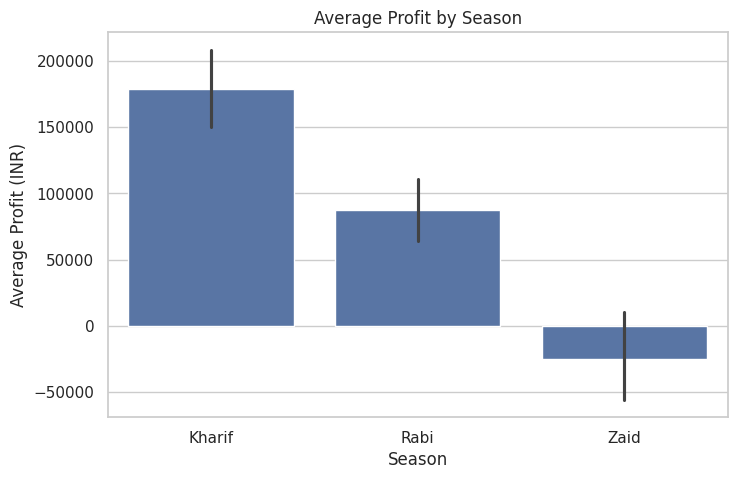

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Profit_INR',
    estimator='mean'
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.show()

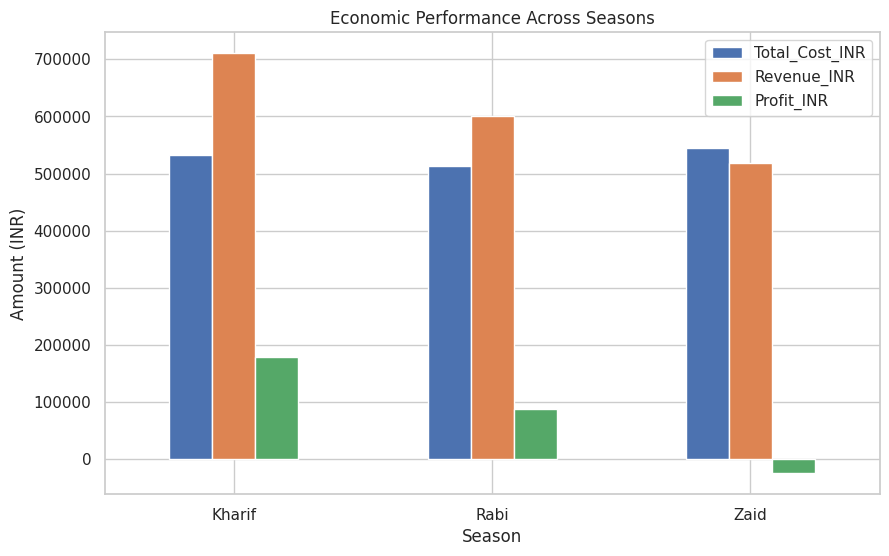

In [20]:
economic_summary = df.groupby('Season')[[
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR'
]].mean()

economic_summary.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Economic Performance Across Seasons')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')
plt.xticks(rotation=0)
plt.show()

### Observation

The comparison of revenue, total cost and profit shows clear differences
in economic performance across seasons. Kharif shows the strongest
average economic performance, followed by Rabi, while Zaid shows the
weakest performance.

The results indicate that higher revenue relative to total cost leads
to better profitability. Zaid has comparatively lower economic returns
and shows negative average profit in the dataset.

In [21]:
crop_summary = df.groupby('Crop').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

crop_summary.sort_values('Profit_INR', ascending=False)

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Crop,,,,,
Sugarcane,46.64,392.41,817187.99,30.48,45.40
Chilli,1.54,12.38,750878.34,2.95,46.06
Cotton,1.23,9.40,124546.92,1.94,45.97
Groundnut,1.32,9.66,44858.12,3.15,46.29
Pulses,0.92,7.40,-4238.05,2.90,46.57
Maize,2.71,21.78,-83978.33,5.60,45.54
Rice,2.43,19.29,-102213.50,1.95,46.50
Wheat,2.11,16.85,-123398.34,4.63,47.85


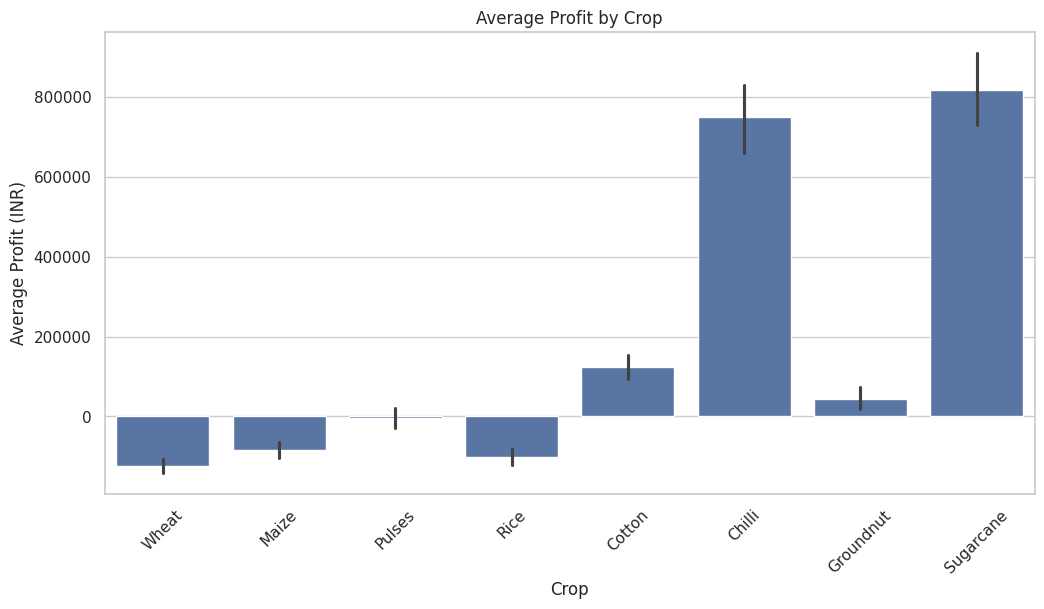

In [22]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x='Crop',
    y='Profit_INR',
    estimator='mean'
)

plt.title('Average Profit by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.show()

### Observation

The economic performance varies considerably across different crops.
Sugarcane has the highest average profit, followed by Chilli and Cotton.
Groundnut shows a relatively lower positive average profit.

Pulses, Maize, Rice and Wheat show negative average profits in the
dataset, indicating that their average production costs exceed their
average revenue.

Overall, Sugarcane and Chilli perform better economically compared with
the other crops in the analyzed dataset.

In [23]:
crop_season_profit = pd.pivot_table(
    df,
    values='Profit_INR',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

crop_season_profit.round(2)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.42,638572.50,448659.09
Cotton,216999.55,107343.59,-53925.34
Groundnut,108265.44,10416.54,-68872.50
Maize,-39332.67,-89133.40,-194049.17
Pulses,43338.90,-14309.14,-139227.81
Rice,-64903.40,-98427.87,-227239.34
Sugarcane,1000790.81,731612.86,583635.80
Wheat,-105871.87,-119954.57,-193208.95


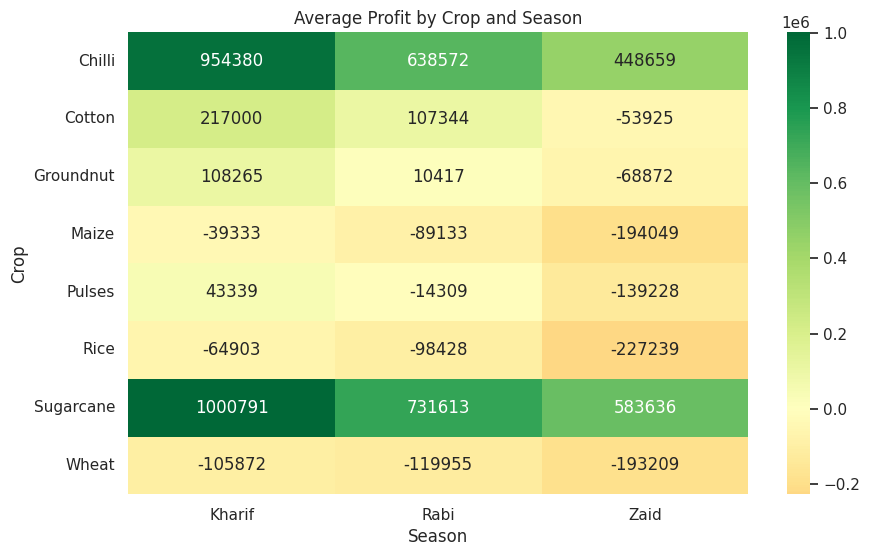

In [24]:
plt.figure(figsize=(10,6))

sns.heatmap(
    crop_season_profit,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    center=0
)

plt.title('Average Profit by Crop and Season')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.show()

### Observation

Profitability varies across crop-season combinations. Sugarcane in the
Kharif season has the highest average profit, followed by Chilli in the
Kharif season. This shows that selecting the right crop for a particular
season can have a significant impact on economic performance.

In [25]:
season_environment = df.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Sunlight_Hours_Day': 'mean',
    'Soil_Moisture_pct': 'mean'
}).round(2)

season_environment

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


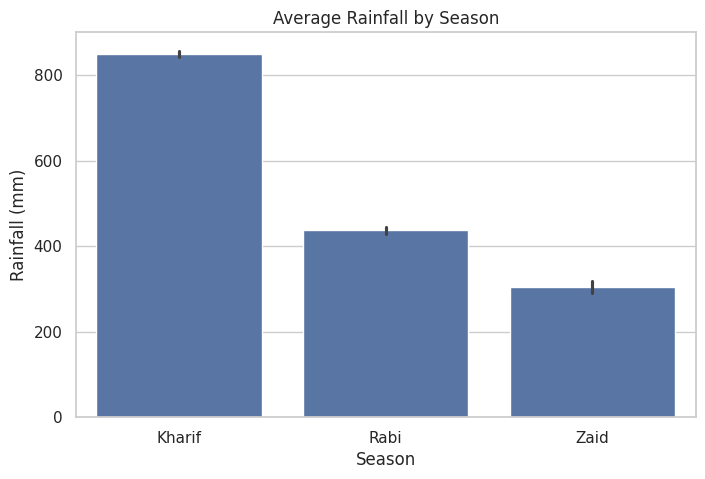

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Rainfall_mm',
    estimator='mean'
)

plt.title('Average Rainfall by Season')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')
plt.show()

### Observation
You can similarly analyze:

temperature,
humidity,
sunlight,
soil moisture.

In [27]:
irrigation_summary = df.groupby(
    ['Season', 'Irrigation_Method']
).agg({
    'Water_Used_m3': 'mean',
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).round(2)

irrigation_summary

Water_Used_m3  Yield_Tonnes_Ha  Profit_INR  \
Season Irrigation_Method                                               
Kharif Drip                     5953.37             7.26   317222.07   
       Flood                    8229.27             4.98   133373.83   
       Rainfed                  3687.52             5.70   158974.13   
       Sprinkler                5863.27             4.66   116880.49   
Rabi   Drip                     5911.41             6.11   187843.22   
       Flood                    7766.83             5.06    58824.80   
       Rainfed                  3298.29             3.93    45232.48   
       Sprinkler                6129.09             5.31    76502.07   
Zaid   Drip                     5837.99             5.85    21291.84   
       Flood                    8113.69             3.98   -69786.78   
       Rainfed                  3879.39             3.06   -79467.26   
       Sprinkler                7324.41             6.14    57909.40   

                          Water_Efficiency_t_per_1000m3  
Season Irrigation_Method                                 
Kharif Drip                                        6.80  
       Flood                                       3.64  
       Rainfed                                     8.85  
       Sprinkler                                   4.62  
Rabi   Drip                                        6.05  
       Flood                                       3.48  
       Rainfed                                     6.87  
       Sprinkler                                   4.64  
Zaid   Drip                                        5.30  
       Flood                                       2.73  
       Rainfed                                     5.48  
       Sprinkler                                   4.86

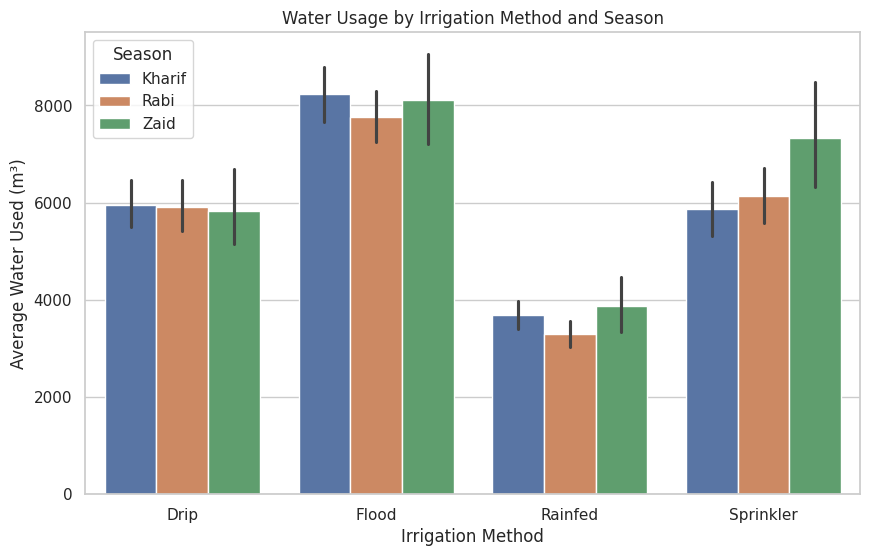

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='Irrigation_Method',
    y='Water_Used_m3',
    hue='Season',
    estimator='mean'
)

plt.title('Water Usage by Irrigation Method and Season')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Water Used (m³)')
plt.show()

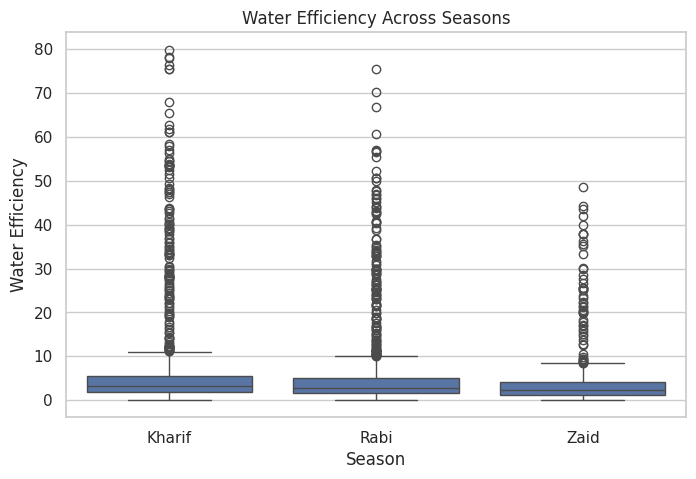

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Season',
    y='Water_Efficiency_t_per_1000m3'
)

plt.title('Water Efficiency Across Seasons')
plt.xlabel('Season')
plt.ylabel('Water Efficiency')
plt.show()

In [30]:
water_efficiency = df.groupby(
    'Irrigation_Method'
)['Water_Efficiency_t_per_1000m3'].mean().sort_values(
    ascending=False
)

water_efficiency

,Water_Efficiency_t_per_1000m3
Irrigation_Method,
Rainfed,7.563784
Drip,6.267129
Sprinkler,4.669805
Flood,3.438853


In [31]:
risk_summary = df.groupby('Season')[
    'Disease_Pest_Risk_pct'
].mean().round(2)

risk_summary

,Disease_Pest_Risk_pct
Season,
Kharif,54.47
Rabi,40.48
Zaid,38.22


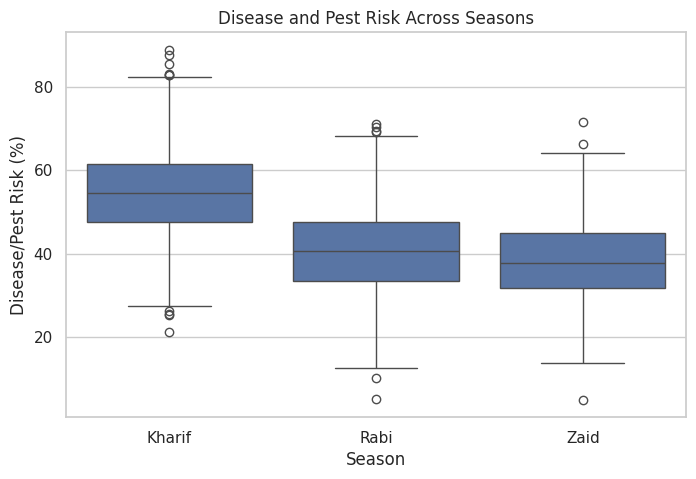

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Season',
    y='Disease_Pest_Risk_pct'
)

plt.title('Disease and Pest Risk Across Seasons')
plt.xlabel('Season')
plt.ylabel('Disease/Pest Risk (%)')
plt.show()

In [33]:
df['Profit_Status'] = np.where(
    df['Profit_INR'] > 0,
    'Profitable',
    'Loss'
)

df['Profit_Status'].value_counts()

,count
Profit_Status,
Profitable,2034
Loss,1966


In [34]:
profit_status = pd.crosstab(
    df['Season'],
    df['Profit_Status'],
    normalize='index'
) * 100

profit_status.round(2)

Profit_Status,Loss,Profitable
Season,,
Kharif,42.21,57.79
Rabi,51.14,48.86
Zaid,64.48,35.52


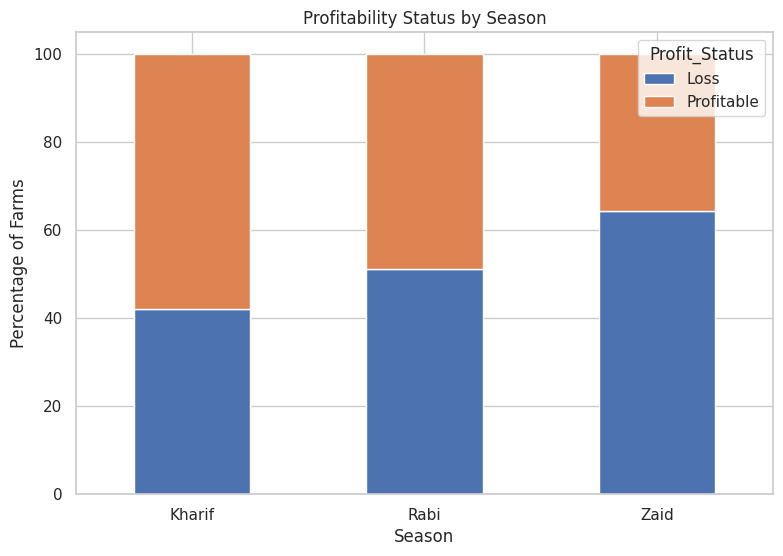

In [35]:
profit_status.plot(
    kind='bar',
    stacked=True,
    figsize=(9,6)
)

plt.title('Profitability Status by Season')
plt.xlabel('Season')
plt.ylabel('Percentage of Farms')
plt.xticks(rotation=0)
plt.show()

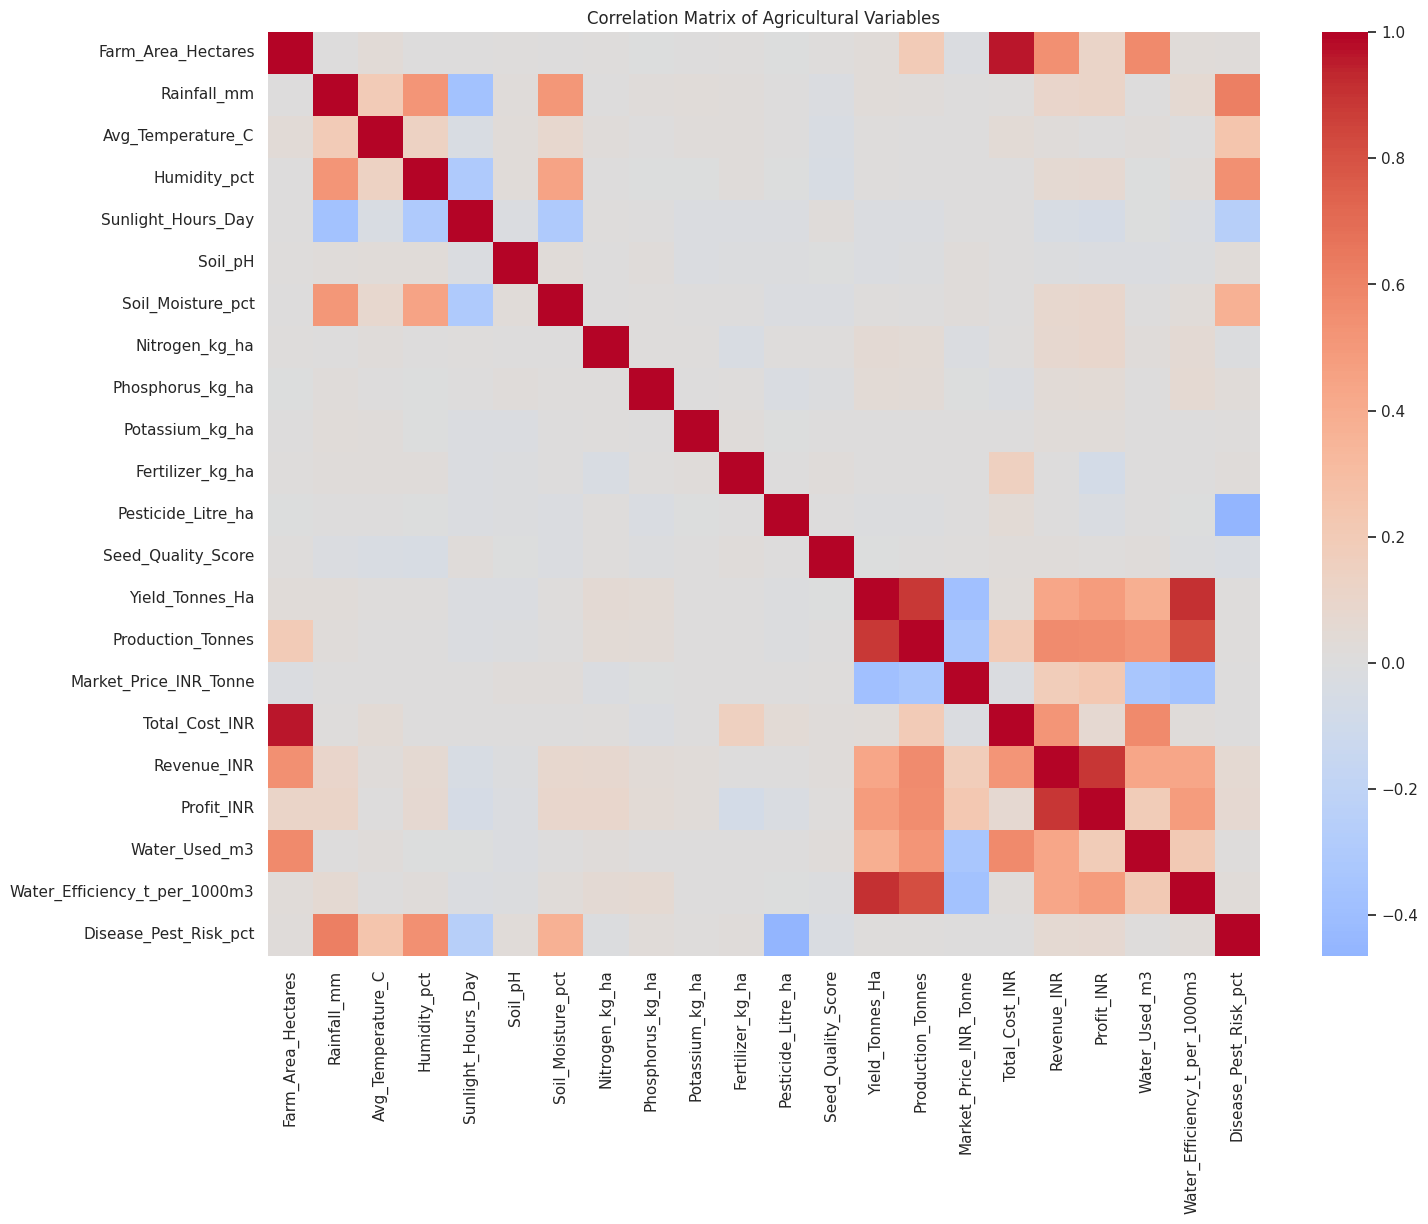

In [36]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    correlation,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Agricultural Variables')
plt.show()

In [37]:
yield_corr = correlation['Yield_Tonnes_Ha'].sort_values(
    ascending=False
)

yield_corr

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941
Rainfall_mm,0.030951
Total_Cost_INR,0.030622


In [38]:
profit_corr = correlation['Profit_INR'].sort_values(
    ascending=False
)

profit_corr

,Profit_INR
Profit_INR,1.000000
Revenue_INR,0.887331
Production_Tonnes,0.554172
Water_Efficiency_t_per_1000m3,0.489487
Yield_Tonnes_Ha,0.488466
Market_Price_INR_Tonne,0.225119
Water_Used_m3,0.190278
Farm_Area_Hectares,0.115241
Rainfall_mm,0.107648
Soil_Moisture_pct,0.091281


### Observation

The correlation analysis shows the relationships between different
agricultural variables. Yield and water efficiency show a positive
relationship, indicating that higher agricultural yield is generally
associated with better water efficiency.

Profit also shows a strong positive relationship with revenue, which
indicates that higher revenue generally contributes to higher
profitability.

The correlation analysis helps identify variables that are closely
associated with agricultural performance. However, correlation does
not imply causation.

In [39]:
kharif_profit = df[df['Season'] == 'Kharif']['Profit_INR']
rabi_profit = df[df['Season'] == 'Rabi']['Profit_INR']
zaid_profit = df[df['Season'] == 'Zaid']['Profit_INR']

anova_result = stats.f_oneway(
    kharif_profit,
    rabi_profit,
    zaid_profit
)

print("F-statistic:", anova_result.statistic)
print("P-value:", anova_result.pvalue)

F-statistic: 34.29175033935195
P-value: 1.7124156677360182e-15


### Observation
So the evidence indicates that average profit differs significantly across seasons.

In [40]:
anova_water = stats.f_oneway(
    df[df['Season'] == 'Kharif']['Water_Efficiency_t_per_1000m3'],
    df[df['Season'] == 'Rabi']['Water_Efficiency_t_per_1000m3'],
    df[df['Season'] == 'Zaid']['Water_Efficiency_t_per_1000m3']
)

print("F-statistic:", anova_water.statistic)
print("P-value:", anova_water.pvalue)

F-statistic: 6.948269603965189
P-value: 0.0009719376945376617


### Observation
This suggests a statistically significant seasonal difference in water efficiency.

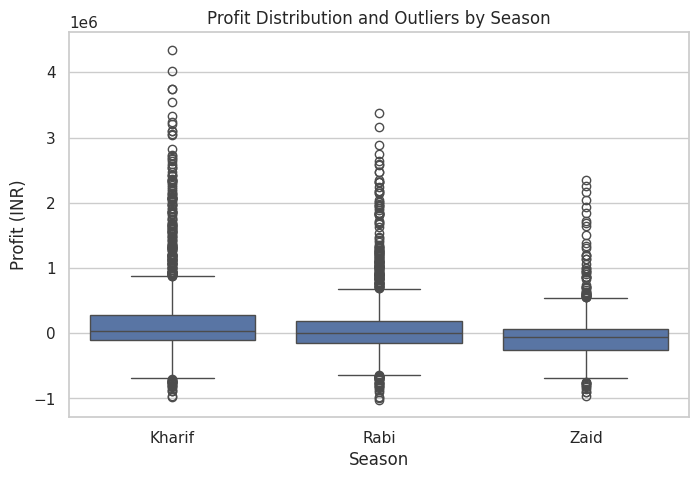

In [41]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Season',
    y='Profit_INR'
)

plt.title('Profit Distribution and Outliers by Season')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')
plt.show()

### Observation

The box plot shows the distribution of profit across different
seasons and highlights the presence of unusually high or low profit
values.

The spread of profit varies across seasons, indicating that farms do
not have the same economic performance within a season. Some extreme
values may represent farms with unusually high revenue, high costs,
or other differences in agricultural conditions.

These outliers should be considered while interpreting average
profitability across seasons.

In [44]:
state_summary = df.groupby('State').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Revenue_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

state_summary.sort_values(
    'Profit_INR',
    ascending=False
)

,Yield_Tonnes_Ha,Profit_INR,Revenue_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
State,,,,,
Punjab,6.12,136025.64,686225.70,5.62,46.00
Maharashtra,5.02,135428.86,650032.67,5.28,46.44
Karnataka,5.69,119422.34,653426.18,5.56,46.06
Tamil Nadu,4.88,117744.75,629093.42,5.31,46.28
Gujarat,5.66,117568.24,654692.86,5.58,45.95
Telangana,5.04,108829.62,628784.53,5.46,46.36
Madhya Pradesh,4.99,86840.76,597558.36,5.27,47.08
Andhra Pradesh,4.63,73453.53,606663.66,5.03,46.72


### Observation
This answer Are seasonal patterns consistent across different regions.

In [45]:
state_season_profit = pd.pivot_table(
    df,
    values='Profit_INR',
    index='State',
    columns='Season',
    aggfunc='mean'
)

state_season_profit.round(2)

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169315.52,26315.71,-84084.87
Gujarat,217051.33,82846.20,-106929.61
Karnataka,201226.21,70952.61,23310.91
Madhya Pradesh,134242.40,61576.26,209.70
Maharashtra,168801.05,159581.50,-40597.60
Punjab,133779.10,169294.52,62109.69
Tamil Nadu,211303.96,70456.86,-15175.20
Telangana,199668.38,62824.60,-34620.78


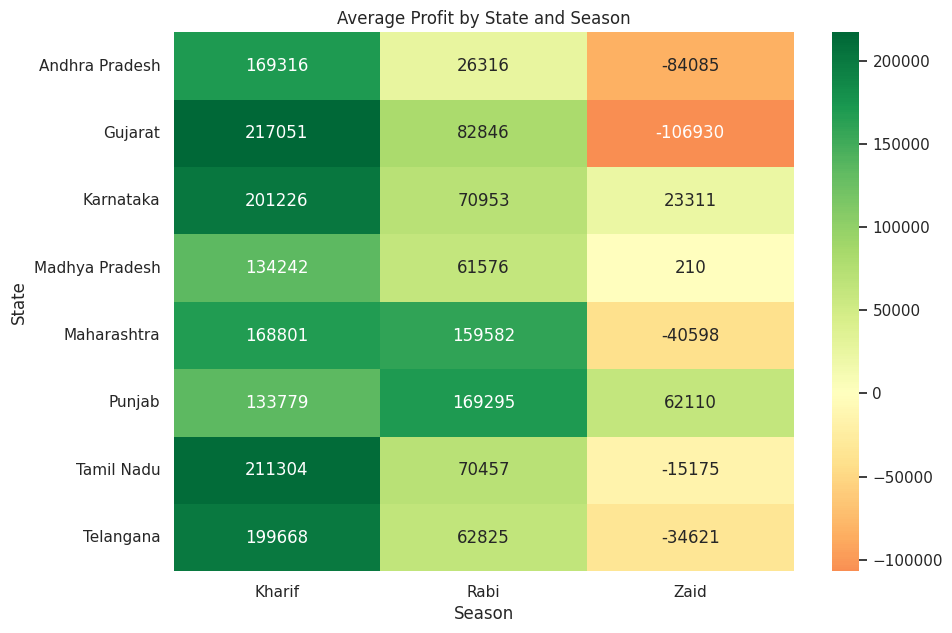

In [46]:
plt.figure(figsize=(10,7))

sns.heatmap(
    state_season_profit,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    center=0
)

plt.title('Average Profit by State and Season')
plt.xlabel('Season')
plt.ylabel('State')
plt.show()

In [47]:
print("========== PROJECT KPIs ==========")

print("Total Farms:", df['Farm_ID'].nunique())
print("Total Records:", len(df))
print("Number of States:", df['State'].nunique())
print("Number of Crops:", df['Crop'].nunique())
print("Number of Seasons:", df['Season'].nunique())

print("\nBest Season by Average Profit:")
print(
    df.groupby('Season')['Profit_INR']
    .mean()
    .idxmax()
)

print("\nBest Season by Average Yield:")
print(
    df.groupby('Season')['Yield_Tonnes_Ha']
    .mean()
    .idxmax()
)

print("\nHighest Average Water Efficiency Season:")
print(
    df.groupby('Season')['Water_Efficiency_t_per_1000m3']
    .mean()
    .idxmax()
)

========== PROJECT KPIs ==========
Total Farms: 4000
Total Records: 4000
Number of States: 8
Number of Crops: 8
Number of Seasons: 3

Best Season by Average Profit:
Kharif

Best Season by Average Yield:
Kharif

Highest Average Water Efficiency Season:
Kharif




*   # Key Findings

1. Agricultural performance varies across Kharif, Rabi and Zaid seasons.

2. Kharif records the highest average yield among the three seasons
   in the analyzed dataset.

3. Kharif also shows the strongest average profitability.

4. Zaid shows comparatively lower average yield, water efficiency
   and profitability.

5. Water usage and water efficiency vary across seasons and
   irrigation methods.

6. Disease and pest risk differs substantially across seasons.

7. Crop performance is not uniform, and crop-season combinations
   should be considered when evaluating agricultural performance.

8. Environmental variables such as rainfall, temperature, humidity
   and soil moisture should be considered when interpreting
   seasonal differences.

9. Statistical analysis can be used to determine whether observed
   seasonal differences are statistically significant.

10. The findings can support evidence-based seasonal agricultural
  planning.



# Recommendations

1. Seasonal planning should consider historical productivity and
   profitability patterns.

2. Farmers and agricultural planners should evaluate crop-season
   combinations rather than selecting crops independently of season.

3. Water-efficient irrigation practices should be encouraged because
   water efficiency shows a strong relationship with yield.

4. Crops and seasons showing consistently weak profitability should
   receive further cost and resource-use investigation.

5. Disease and pest risk should be considered during seasonal
   agricultural planning.

6. Regional differences should be considered when developing
   agricultural strategies.

7. Future analysis can use predictive models to forecast yield,
   profitability and agricultural risk.

# Conclusion

This project analyzed agricultural performance across different
seasons, crops and geographical regions.

The analysis examined productivity, environmental conditions, resource
usage, water efficiency, disease and pest risk and economic
performance.

The results demonstrate that agricultural performance varies across
seasons and crop-season combinations. Statistical and correlation
analysis also helped identify significant differences and important
relationships within the dataset.

Overall, the analysis provides evidence-based insights that can
support better seasonal agricultural planning and resource management.